## Imports

In [ ]:
#Mount Google Drive (if running on Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define paths - Update these to where you uploaded the dataset
# Assuming structure: /content/drive/MyDrive/.../images and /content/drive/MyDrive/.../masks
DATA_DIR = '/content/drive/MyDrive/BrainTumor'
IMAGE_DIR = os.path.join(DATA_DIR, 'images')
MASK_DIR = os.path.join(DATA_DIR, 'masks')

# Image Parameters
IMG_WIDTH = 128
IMG_HEIGHT = 128
CHANNELS = 3
NUM_CLASSES = 1 # Binary segmentation (Tumor vs Background)

In [ ]:
def load_data_paths(img_dir, mask_dir):
    img_paths = []
    mask_paths = []

    # Assuming filenames match: image.png and image_mask.png or similar
    # Adjust the sorting/matching logic based on your specific filenames
    images = sorted(os.listdir(img_dir))
    masks = sorted(os.listdir(mask_dir))

    for img, mask in zip(images, masks):
        img_paths.append(os.path.join(img_dir, img))
        mask_paths.append(os.path.join(mask_dir, mask))

    return img_paths, mask_paths

def read_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = image / 255.0  # Normalize to [0,1]
    return image

def read_mask(mask_path):
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_HEIGHT, IMG_WIDTH))
    # Normalize mask to be 0 or 1 (Binary)
    mask = mask / 255.0
    mask = tf.round(mask) # Ensure binary values
    return mask

def preprocess_path(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)
    return image, mask

# 1. Load Paths
img_paths, mask_paths = load_data_paths(IMAGE_DIR, MASK_DIR)

# 2. Create TensorFlow Dataset
dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
dataset = dataset.map(preprocess_path, num_parallel_calls=tf.data.AUTOTUNE)

# 3. Split Train/Test
VAL_SPLIT = 0.2
DATA_SIZE = len(img_paths)
val_size = int(DATA_SIZE * VAL_SPLIT)
train_size = DATA_SIZE - val_size

train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

# 4. Batch and Prefetch
BATCH_SIZE = 16
train_batches = train_dataset.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
val_batches = val_dataset.cache().batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Training samples: {train_size}, Validation samples: {val_size}")

Training samples: 2452, Validation samples: 612


3. IoU Definition and JustificationIntersection over Union (IoU), also known as the Jaccard Index, is a metric used to evaluate the overlap between two bounding boxes or masks.Definition:$$IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$In terms of predicted mask ($P$) and ground truth ($G$):$$IoU = \frac{|P \cap G|}{|P \cup G|}$$Why use IoU instead of Accuracy for Semantic Segmentation?Class Imbalance: In medical segmentation (like brain tumors), the "tumor" pixels (foreground) usually occupy a tiny fraction of the image compared to the "healthy tissue" or "background" pixels.The Accuracy Trap: If 98% of the image is background, a model that predicts "all background" (no tumor found) will achieve 98% accuracy, despite being useless.IoU Benefit: IoU penalizes false positives and false negatives heavily. A score of 0 means no overlap, and 1 means perfect overlap. It forces the model to actually find the tumor to get a good score.

In [ ]:
def double_conv_block(x, n_filters):
    # Conv2D then ReLU activation
    x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
    x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
    return x

def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = layers.MaxPool2D(2)(f)
    p = layers.Dropout(0.3)(p)
    return f, p

def upsample_block(x, conv_features, n_filters):
    # Upsample
    x = layers.Conv2DTranspose(n_filters, 3, 2, padding="same")(x)
    # Concatenate
    x = layers.concatenate([x, conv_features])
    x = layers.Dropout(0.3)(x)
    # Conv2D twice with ReLU activation
    x = double_conv_block(x, n_filters)
    return x

def build_unet_model():
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))

    # Encoder
    f1, p1 = downsample_block(inputs, 64)
    f2, p2 = downsample_block(p1, 128)
    f3, p3 = downsample_block(p2, 256)
    f4, p4 = downsample_block(p3, 512)

    # Bottleneck
    bottleneck = double_conv_block(p4, 1024)

    # Decoder
    u6 = upsample_block(bottleneck, f4, 512)
    u7 = upsample_block(u6, f3, 256)
    u8 = upsample_block(u7, f2, 128)
    u9 = upsample_block(u8, f1, 64)

    # Output layer: 1 filter for binary mask, Sigmoid activation for 0-1 probability
    outputs = layers.Conv2D(1, 1, padding="same", activation="sigmoid")(u9)

    unet_model = tf.keras.Model(inputs, outputs, name="U-Net")
    return unet_model

model = build_unet_model()
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ dropout_2[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 512) │          0 │ max_pooling2d_3[

 Total params: 34,513,345 (131.66 MB)

 Trainable params: 34,513,345 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 757s 3s/step - accuracy: 0.9632 - iou: 0.0062 - loss: 0.4382 - val_accuracy: 0.9813 - val_iou: 0.0000e+00 - val_loss: 0.0688
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 38s 246ms/step - accuracy: 0.9860 - iou: 0.0000e+00 - loss: 0.0539 - val_accuracy: 0.9813 - val_iou: 0.0000e+00 - val_loss: 0.0588
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 39s 252ms/step - accuracy: 0.9861 - iou: 0.0444 - loss: 0.0461 - val_accuracy: 0.9843 - val_iou: 0.1696 - val_loss: 0.0528
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 39s 254ms/step - accuracy: 0.9874 - iou: 0.1915 - loss: 0.0434 - val_accuracy: 0.9849 - val_iou: 0.2044 - val_loss: 0.0578
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 39s 256ms/step - accuracy: 0.9883 - iou: 0.2459 - loss: 0.0385 - val_accuracy: 0.9857 - val_iou: 0.3926 - val_loss: 0.0516
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.9885 - iou: 0.2887 - loss: 0.0354 - val_accuracy: 0.9842 - val_iou: 0.4001 - val_loss: 0.0472
Epoch 7/15
1

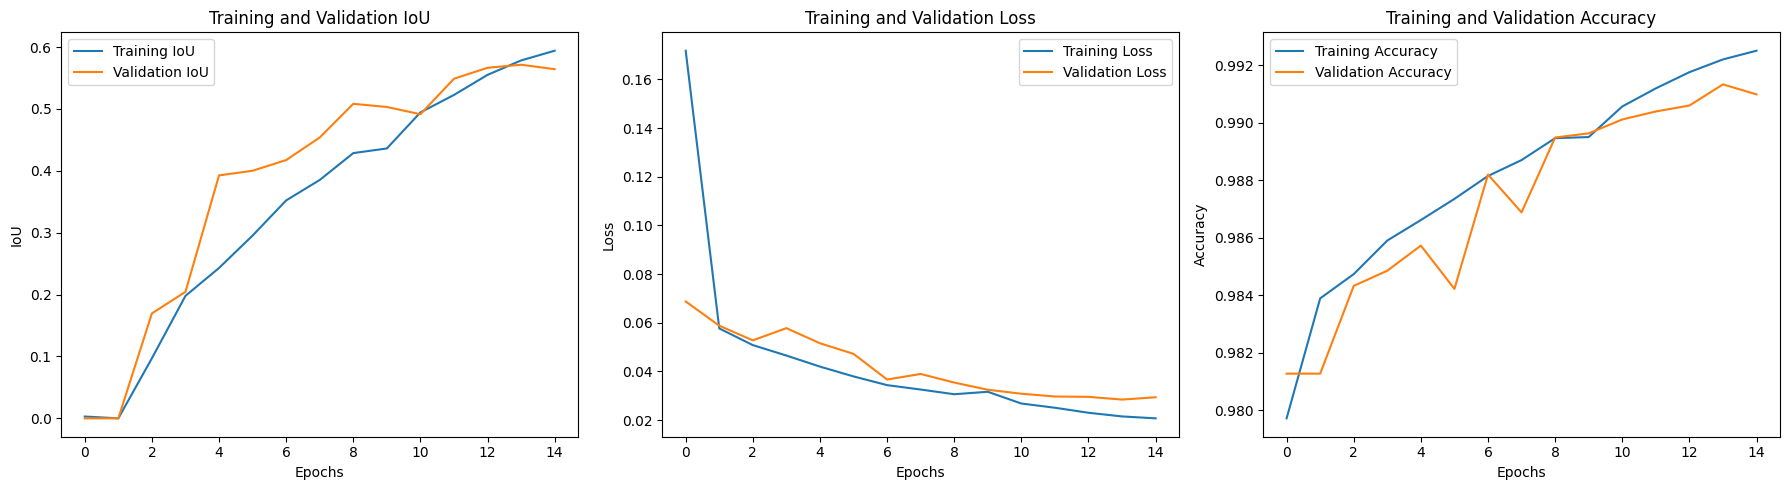

In [ ]:
iou_metric = tf.keras.metrics.BinaryIoU(target_class_ids=[1], name='iou')

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy', iou_metric])

# Train
EPOCHS = 15
history = model.fit(train_batches,
                    epochs=EPOCHS,
                    validation_data=val_batches)

# Show Training Results
plt.figure(figsize=(18, 5)) # Adjusted figure size for 3 plots

# Plot IoU
plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns, 1st plot
plt.plot(history.history['iou'], label='Training IoU')
plt.plot(history.history['val_iou'], label='Validation IoU')
plt.title('Training and Validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()

# Plot Loss
plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns, 2nd plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 3, 3) # Added for accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


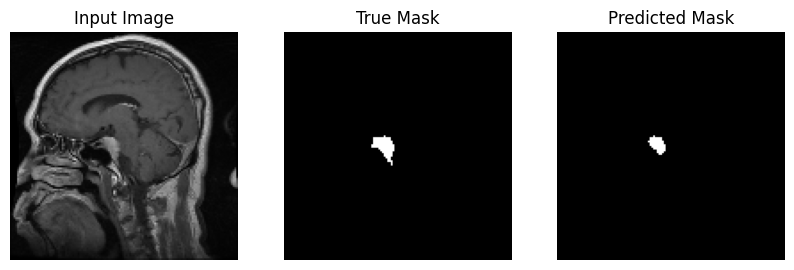

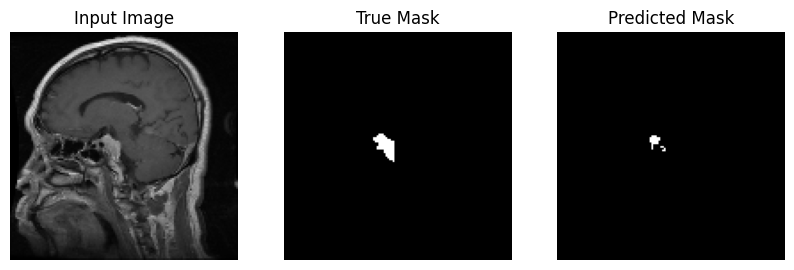

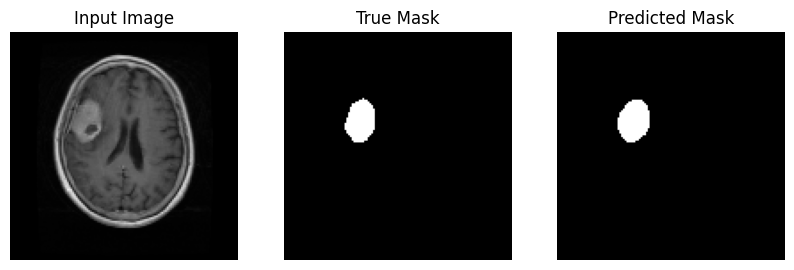

In [ ]:
def show_predictions(dataset=None, num=3):
    if dataset:
        for image, mask in dataset.take(1):
            pred_mask = model.predict(image)

            # Convert probabilities to binary mask (threshold 0.5)
            pred_mask = tf.where(pred_mask > 0.5, 1.0, 0.0)

            for i in range(num):
                plt.figure(figsize=(10, 10))

                plt.subplot(1, 3, 1)
                plt.title("Input Image")
                plt.imshow(image[i])
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.title("True Mask")
                plt.imshow(tf.squeeze(mask[i]), cmap='gray')
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.title("Predicted Mask")
                plt.imshow(tf.squeeze(pred_mask[i]), cmap='gray')
                plt.axis('off')

                plt.show()

# Show results on validation set
show_predictions(val_batches, num=3)
